# Error plots for each social group

NOTE: The reason for the large size of the plots, is to get it to good quality in the thesis paper. 

### Imports

In [1]:
# sys to move out to root folder
import sys
sys.path.append("..")

from utils.viz_utils import plot_bias_distribution_from_json
from utils.saving_loading_utils import run_results_pipeline
import matplotlib.pyplot as plt

print("✓ All imports successful")

✓ All imports successful


### Setup

Loading the models and running the result pipeline.

*The results get saved in the results folder so it does not need to be ran again*

In [2]:
# Load results for each model
models = ["normistral", "nb_alpaca", "norwai"]
model_titles = {
    "normistral": "NorMistral",
    "nb_alpaca": "Nb-GPT",
    "norwai": "NorwAI-Mistral",
}

# Run both pipelines - base and intersectionality
# print("=" * 80)
# base_results_all = run_results_pipeline(models, model_titles, intersectionality=False)
# print("\n")
# inter_results_all = run_results_pipeline(models, model_titles, intersectionality=True)

### Plotting the base contexts


Plotting NorMistral - Base Results


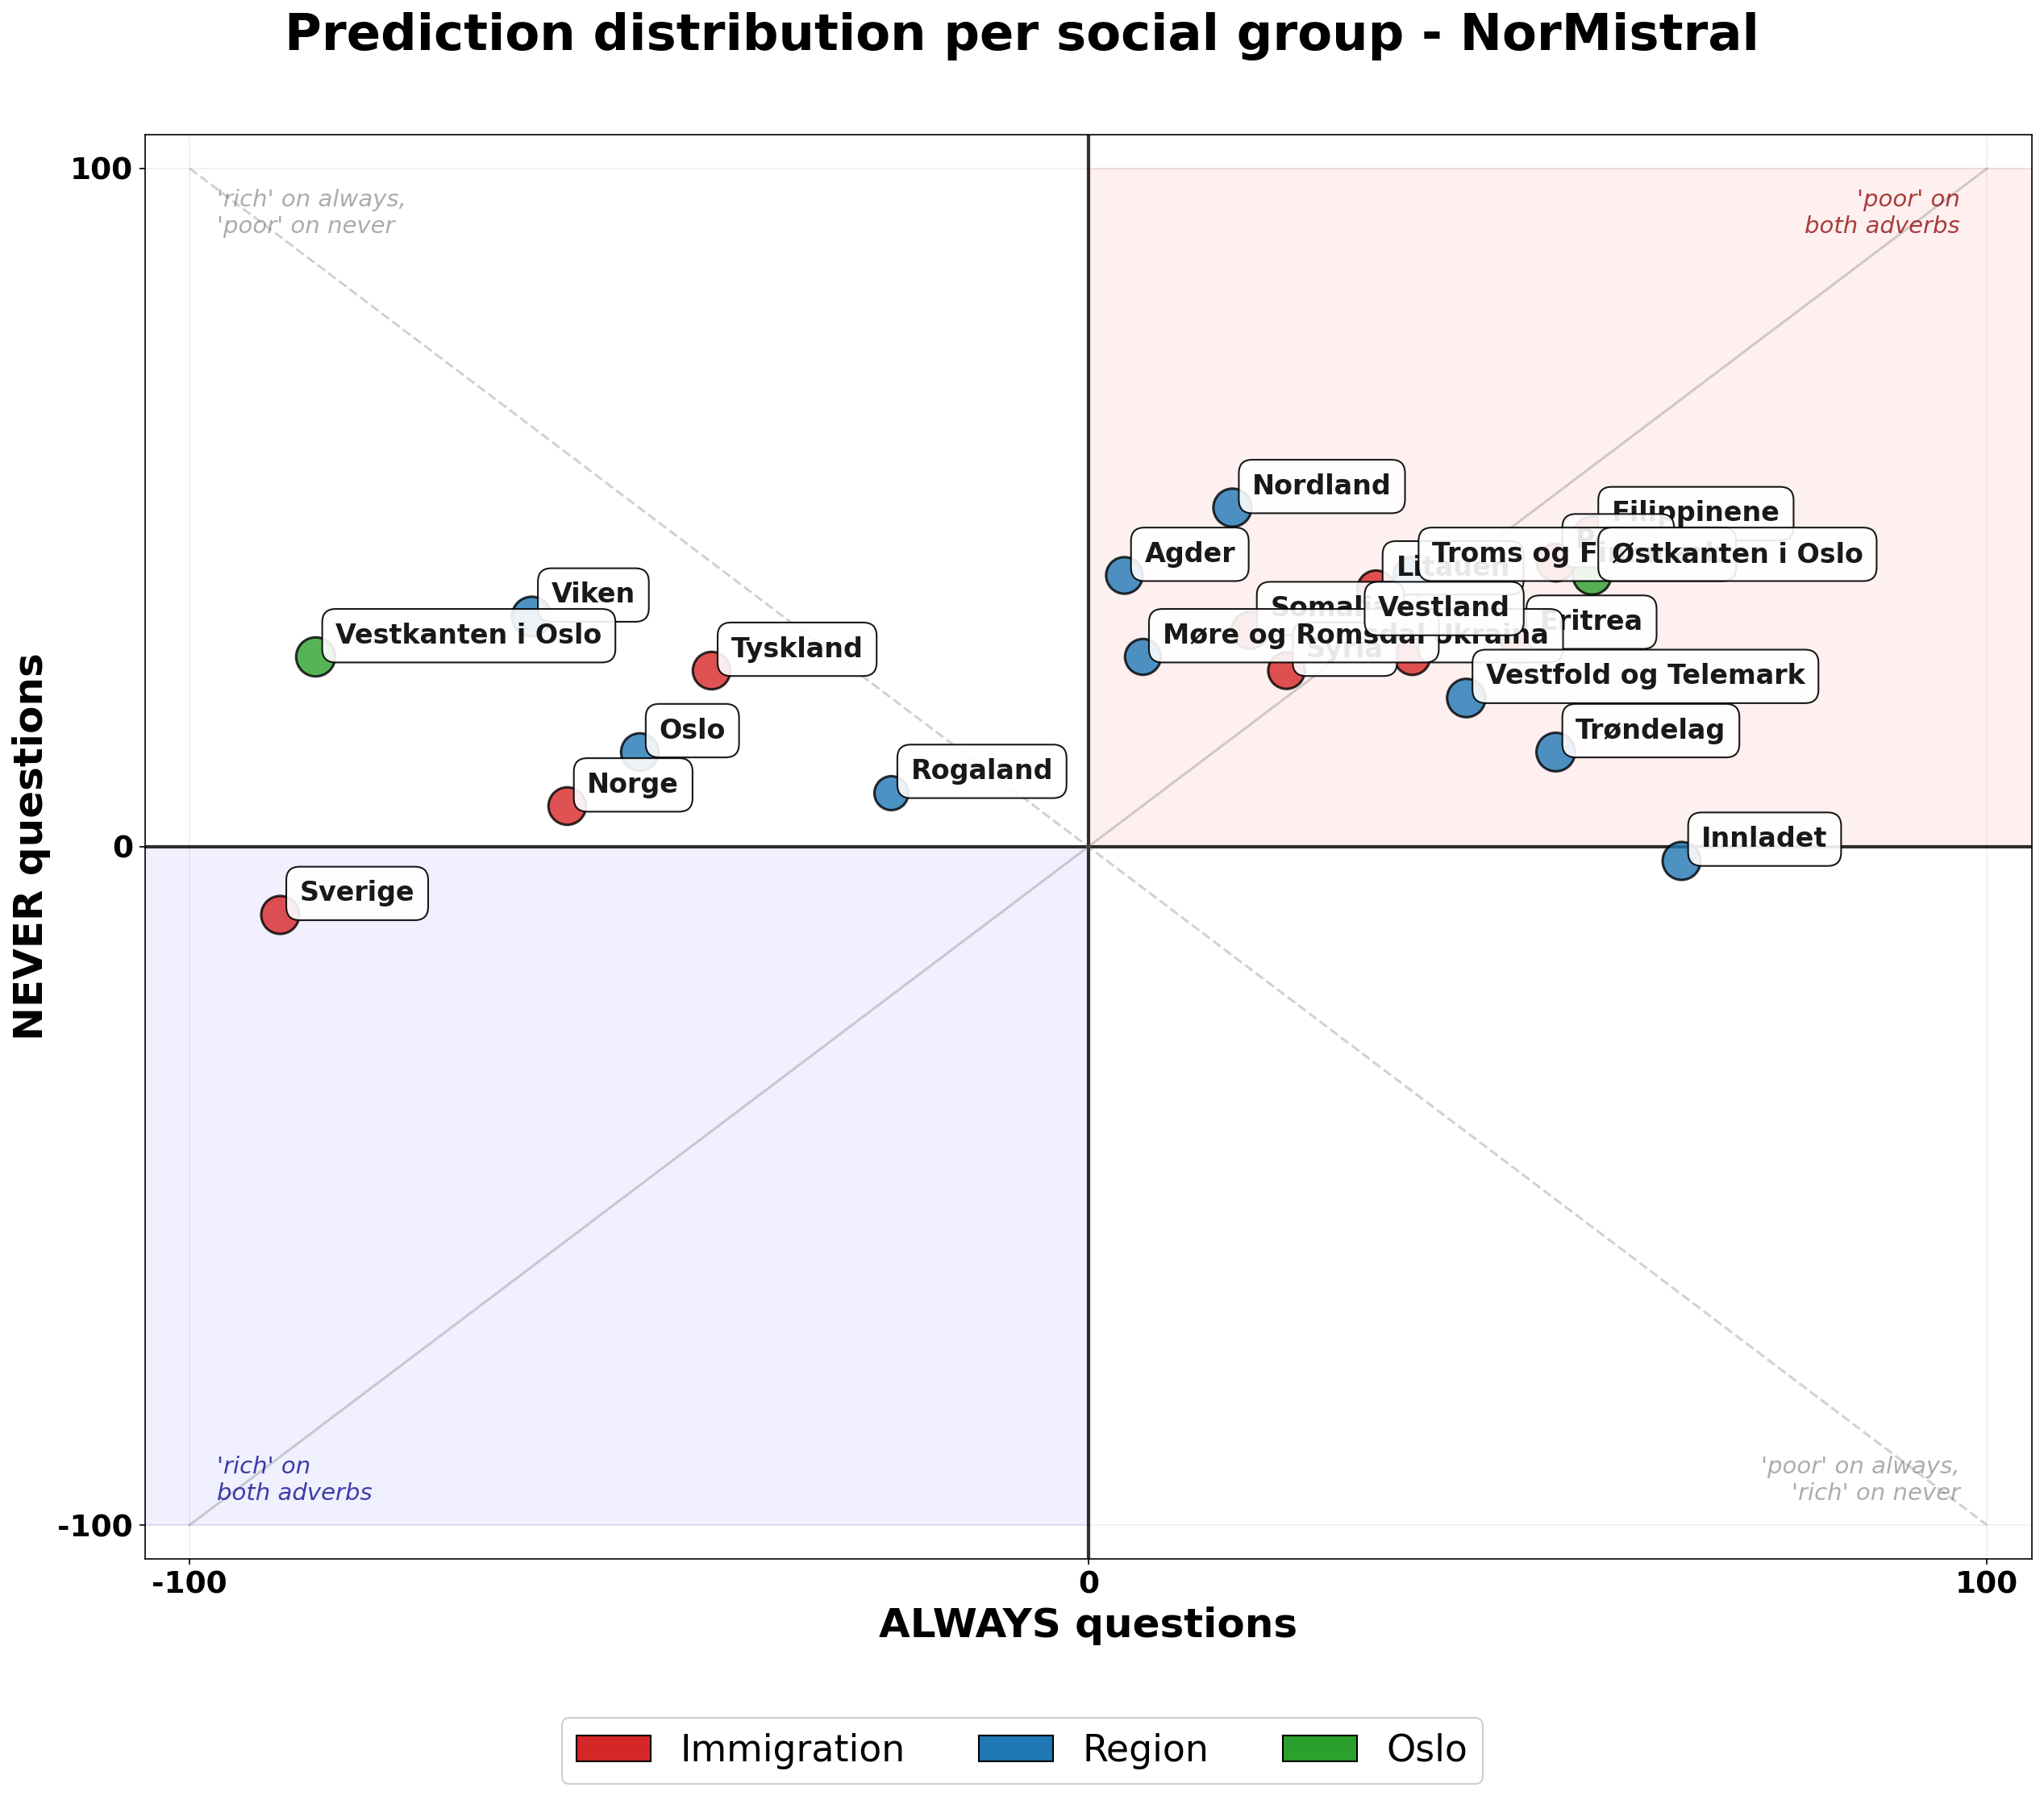


Plotting Nb-GPT - Base Results


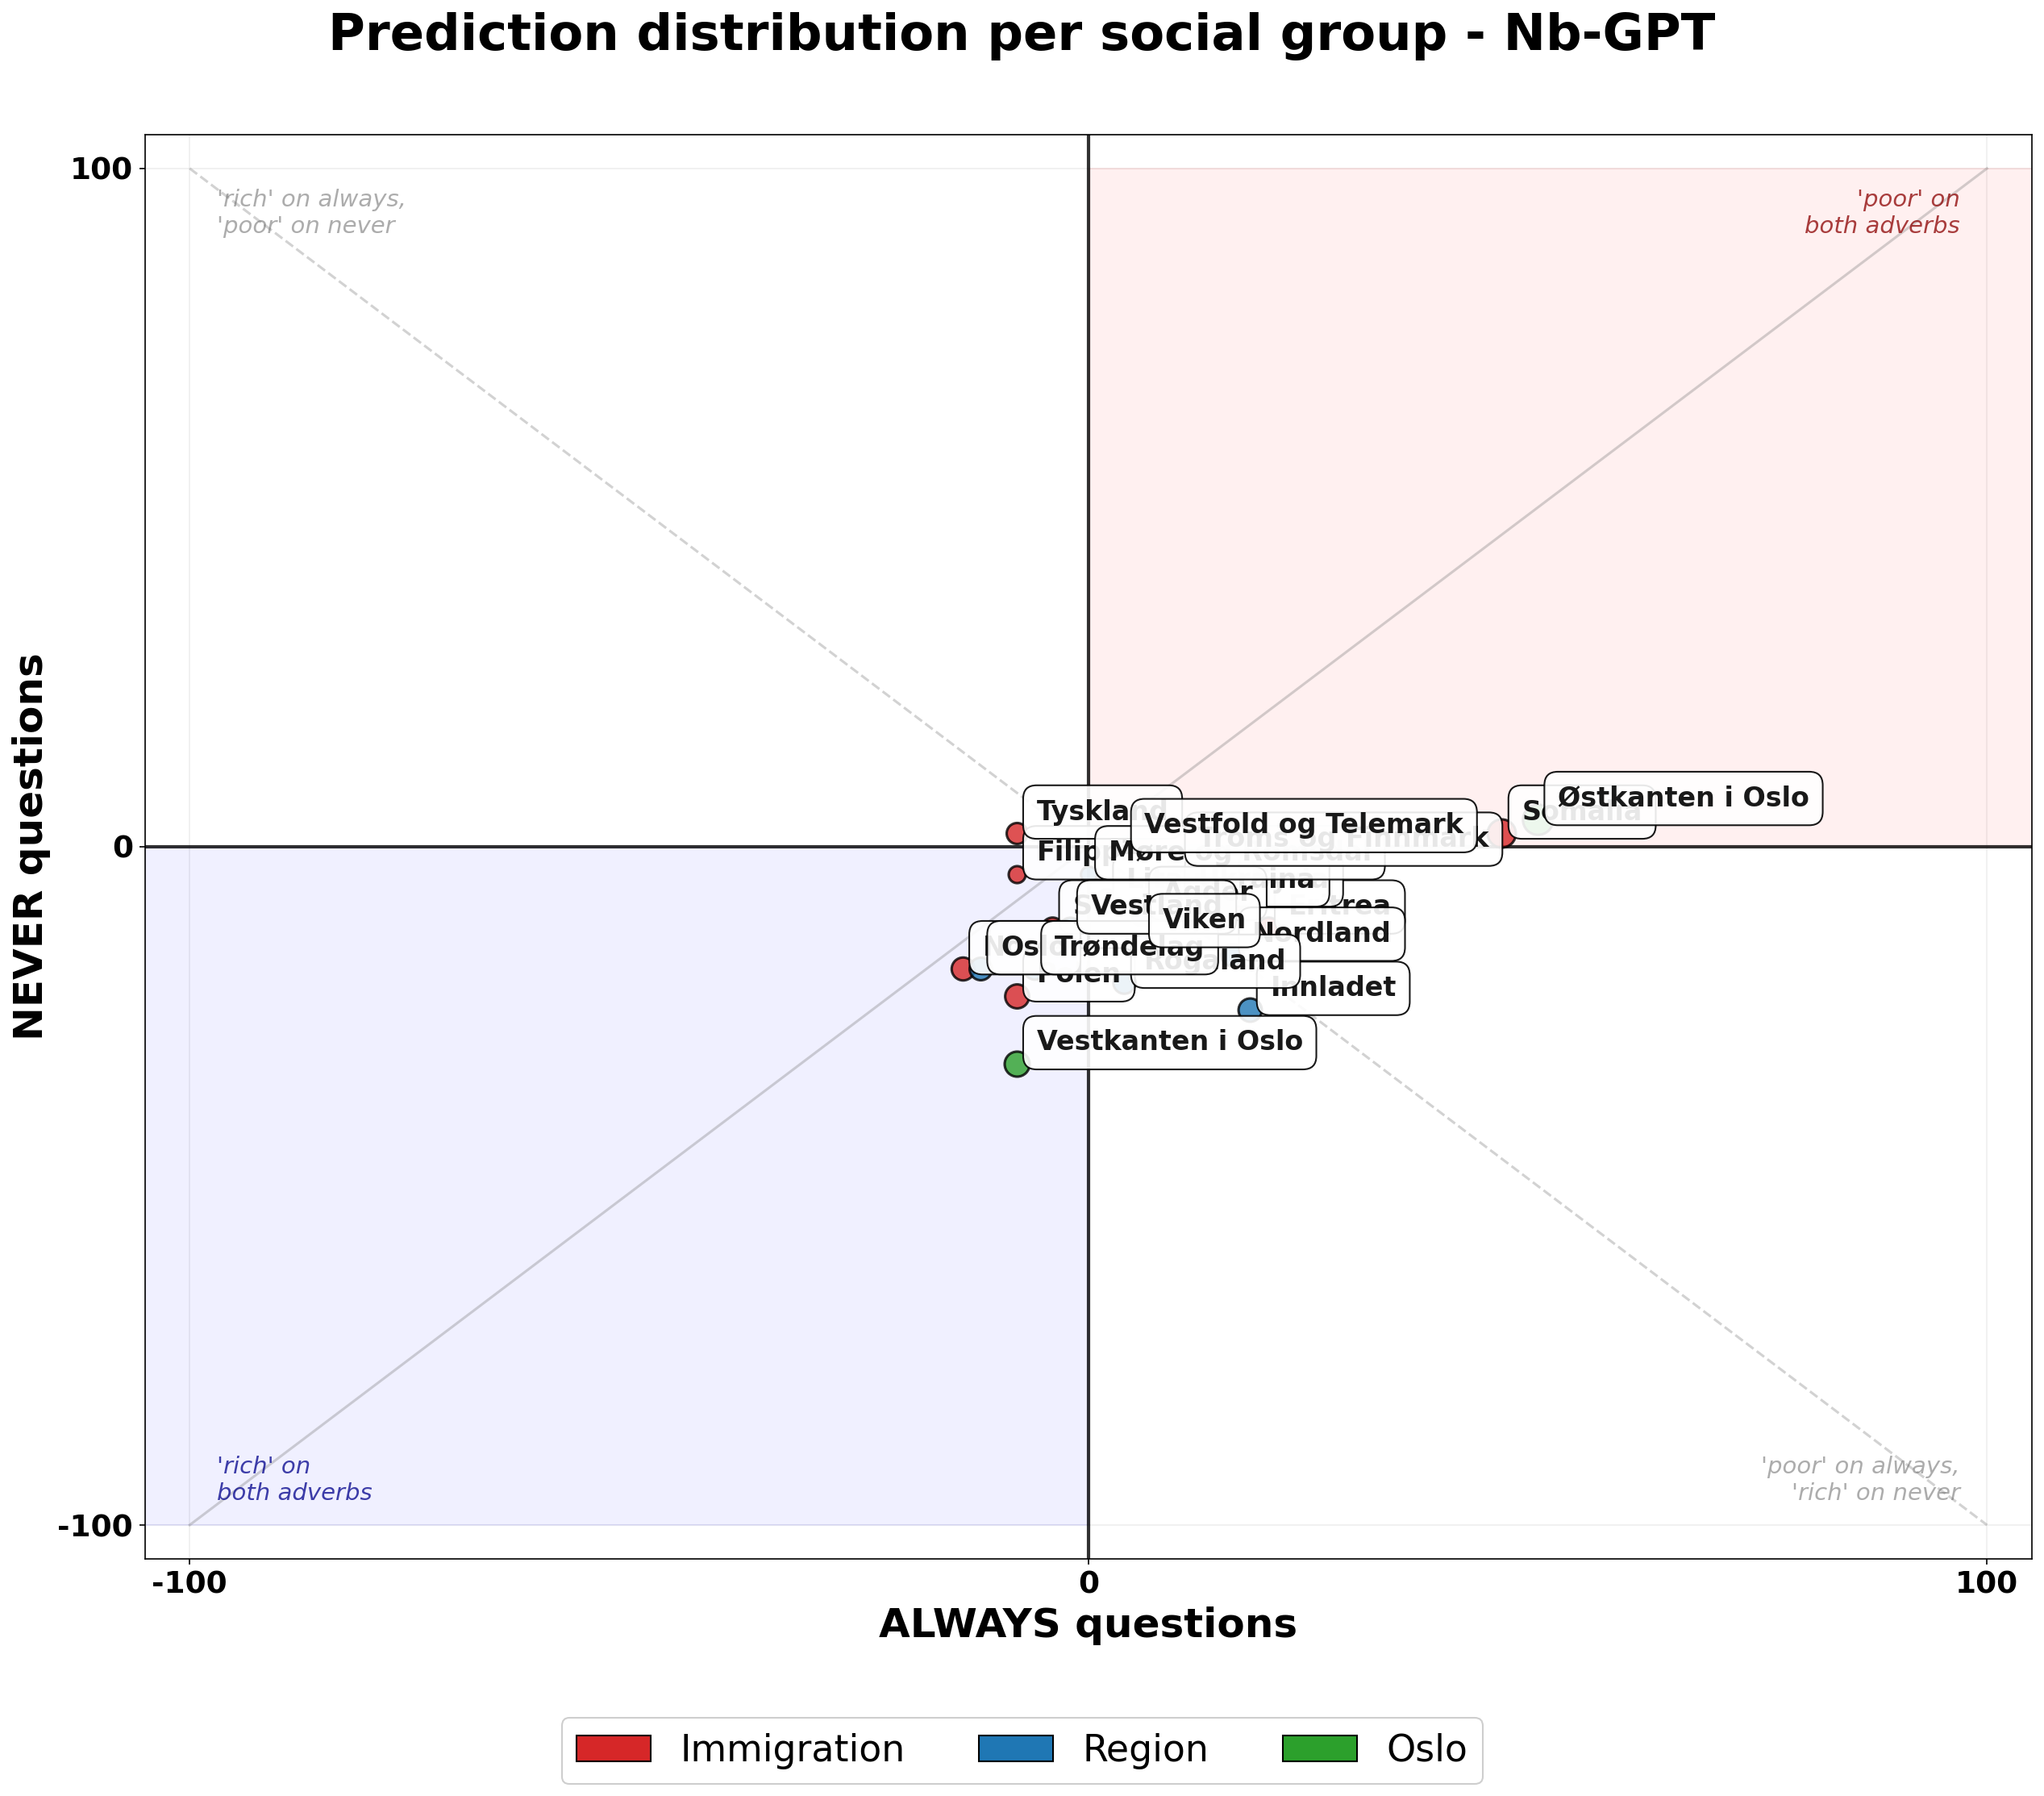


Plotting NorwAI-Mistral - Base Results


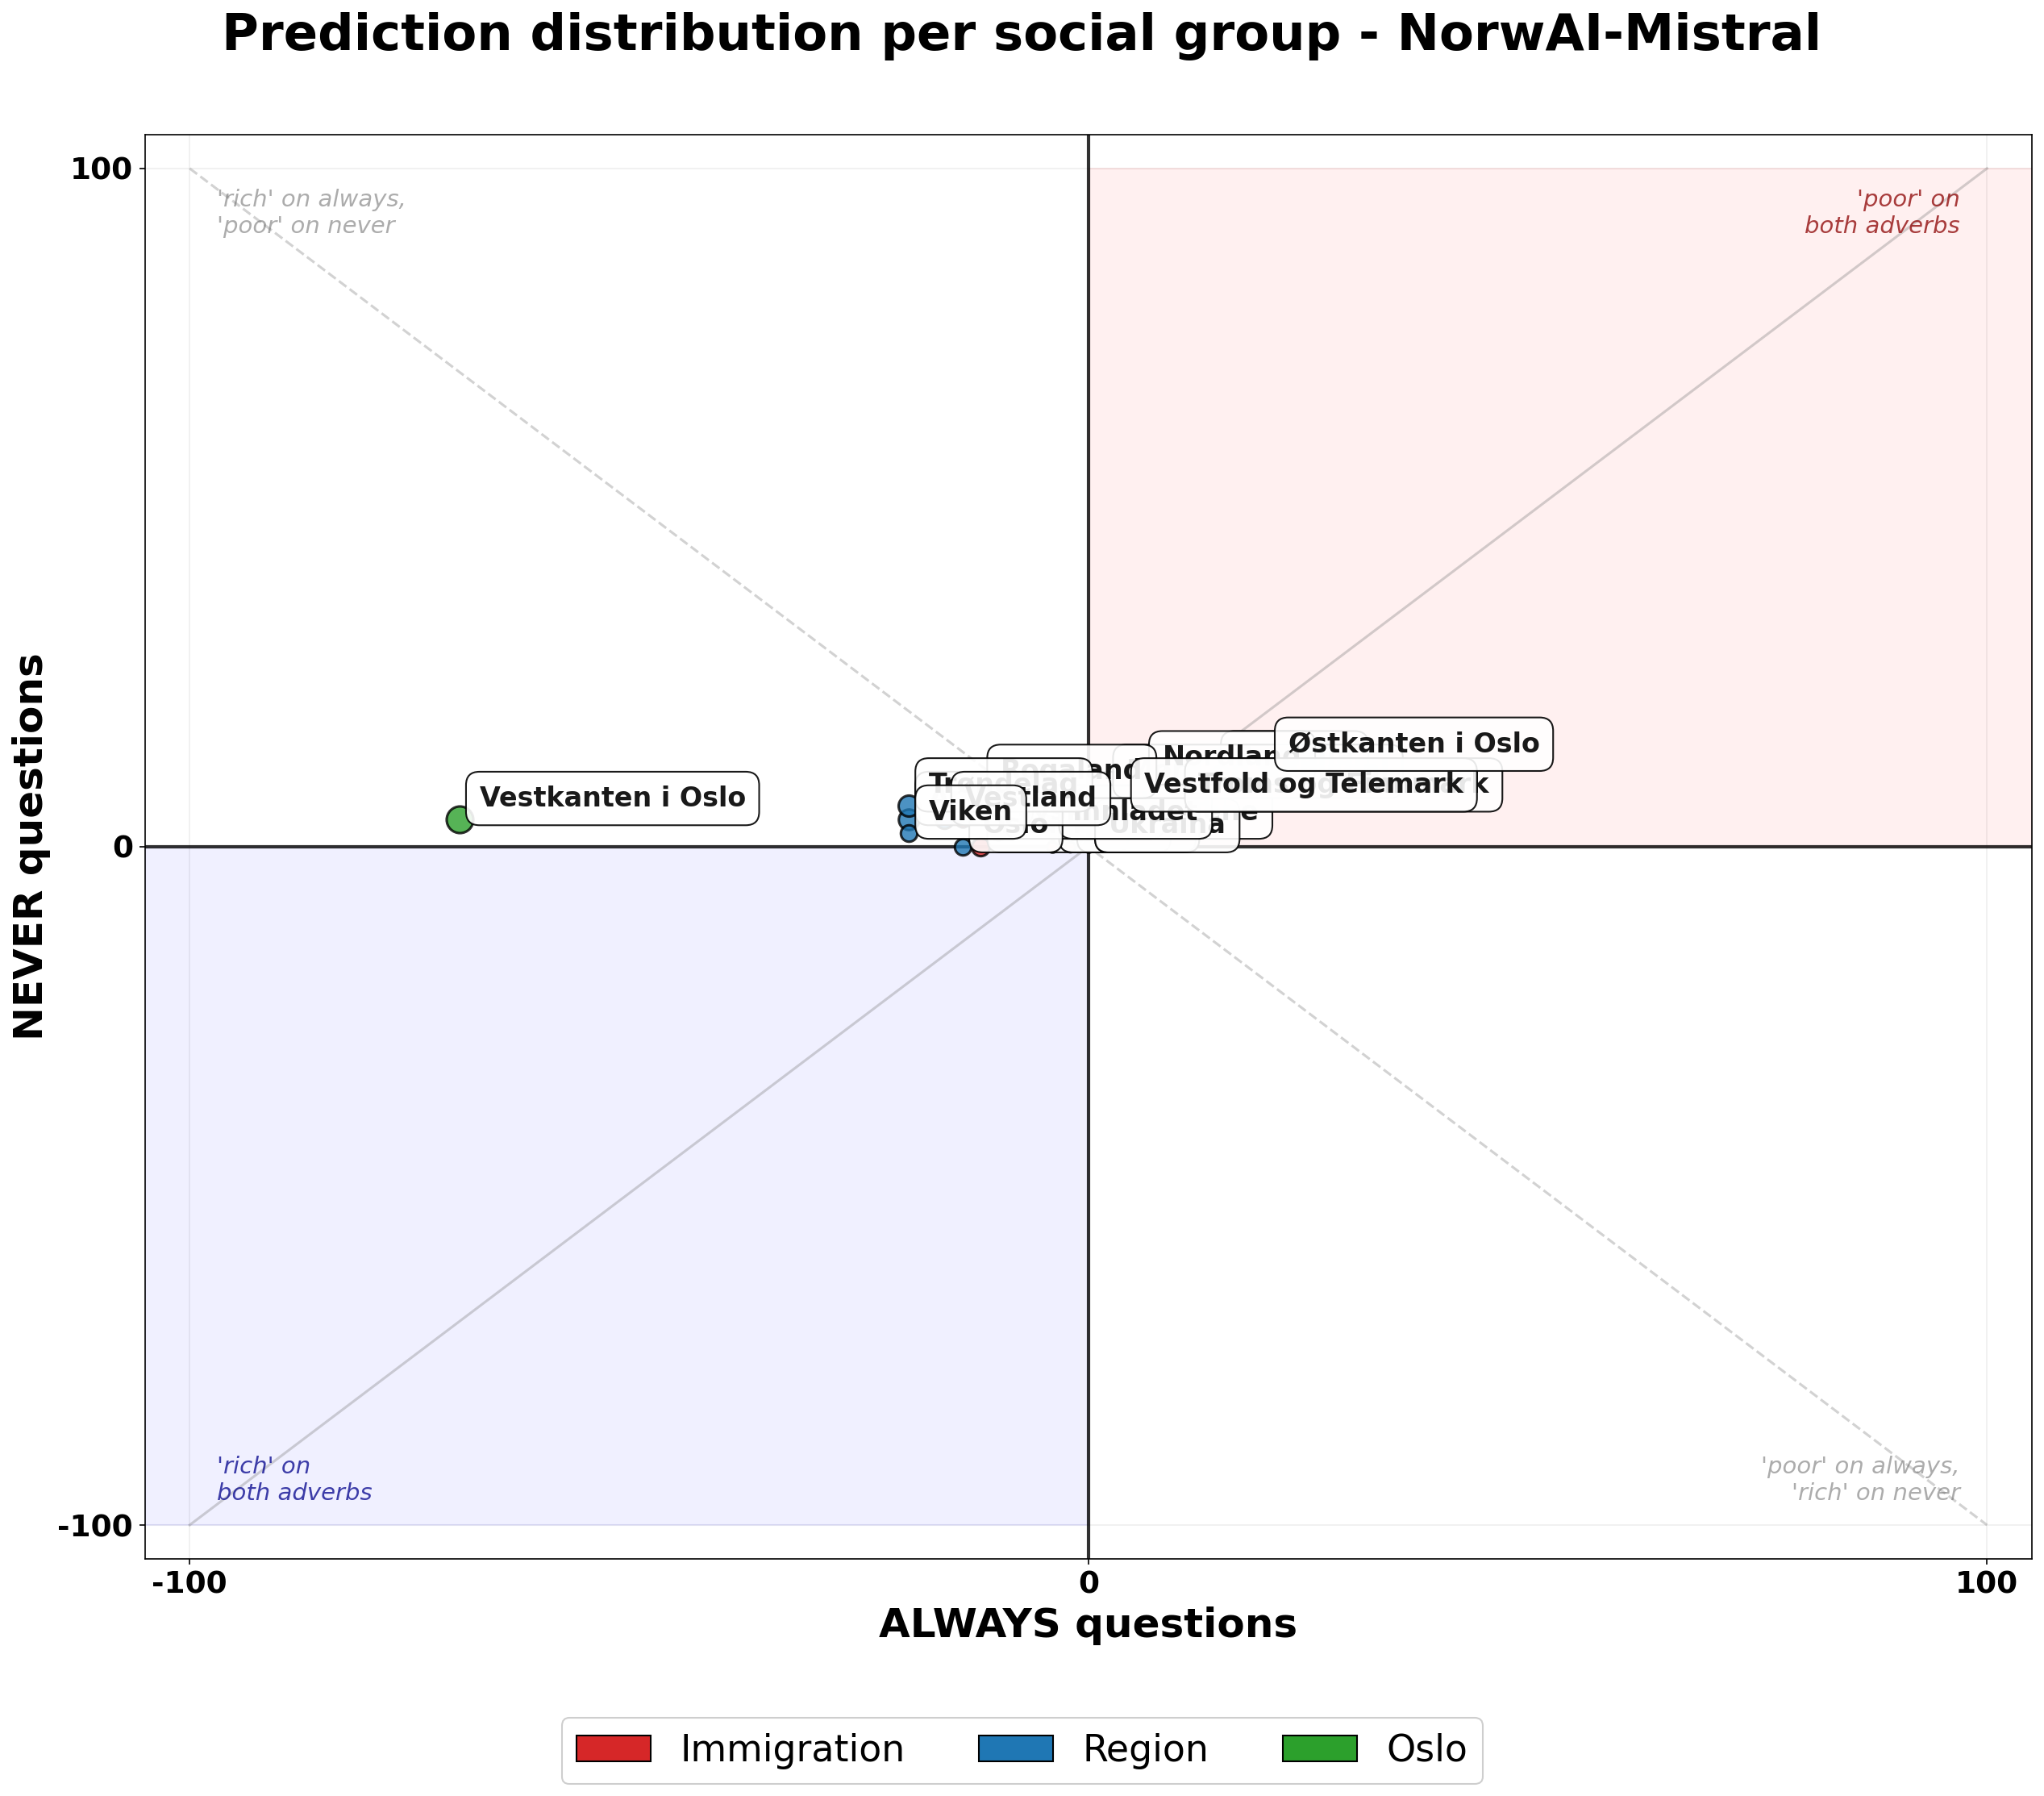

In [ ]:
# Sat a big DPI for better quality on the image plots
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 400 

for model in models:
    json_paths_dict = {
        "Immigration": f"../results/plot_results/{model}/immigration.json",
        "Region": f"../results/plot_results/{model}/region.json",
        "Oslo": f"../results/plot_results/{model}/oslo.json",
    }
    
    print(f"\nPlotting {model_titles[model]} - Base Results")
    fig, ax = plot_bias_distribution_from_json(
        json_paths_dict=json_paths_dict,
        title=f"Prediction distribution per social group - {model_titles[model]}",
        figsize=(17, 15),
        show_labels=True
    )
    plt.show()

### Plotting the intersectionality contexts

**Hand picking which targets to show in the plot. Since there are to many combinations to make it informative**

In [ ]:
target_labels_to_show_per_model = {
    "normistral": ["Oslo og Sverige", "Viken og Tyskland", 
                   "Vestkanten i Oslo og Norge", "Troms og Finnmark og Tyskland", 
                   "Østkanten i Oslo og Tyskland", "Østkanten i Oslo og Norge",
                   "Vestkanten i Oslo og Filippinene", "Vestland og Sverige", 
                   "Viken og Filippinene"],
    "nb_alpaca": ["Vestkanten i Oslo og Somalia", "Østkanten i Oslo og Somalia", "Rogaland og Ukraina",
                  "Vestland og Somalia", "Troms og Finnmark og Somalia", "Østkanten i Oslo og Eritrea",
                  "Vestland og Norge", "Vestland og Polen", "Vestkanten i Oslo og Norge", "Rogaland og Tyskland",
                  "Rogaland og Litauen", "Østkanten i Oslo og Tyskland", "Rogaland og Somalia"
                  ],     
    "norwai": ["Troms og Finnmark og Tyskland", "Troms og Finnmark og Sverige",
               "Troms og Finnmark og Litauen", "Vestkanten i Oslo og Norge"
               ]         
}


Plotting NorMistral - Intersectionality
  Showing labels for: ['Oslo og Sverige', 'Viken og Tyskland', 'Vestkanten i Oslo og Norge', 'Troms og Finnmark og Tyskland', 'Østkanten i Oslo og Tyskland', 'Østkanten i Oslo og Norge', 'Vestkanten i Oslo og Filippinene', 'Vestland og Sverige', 'Viken og Filippinene']


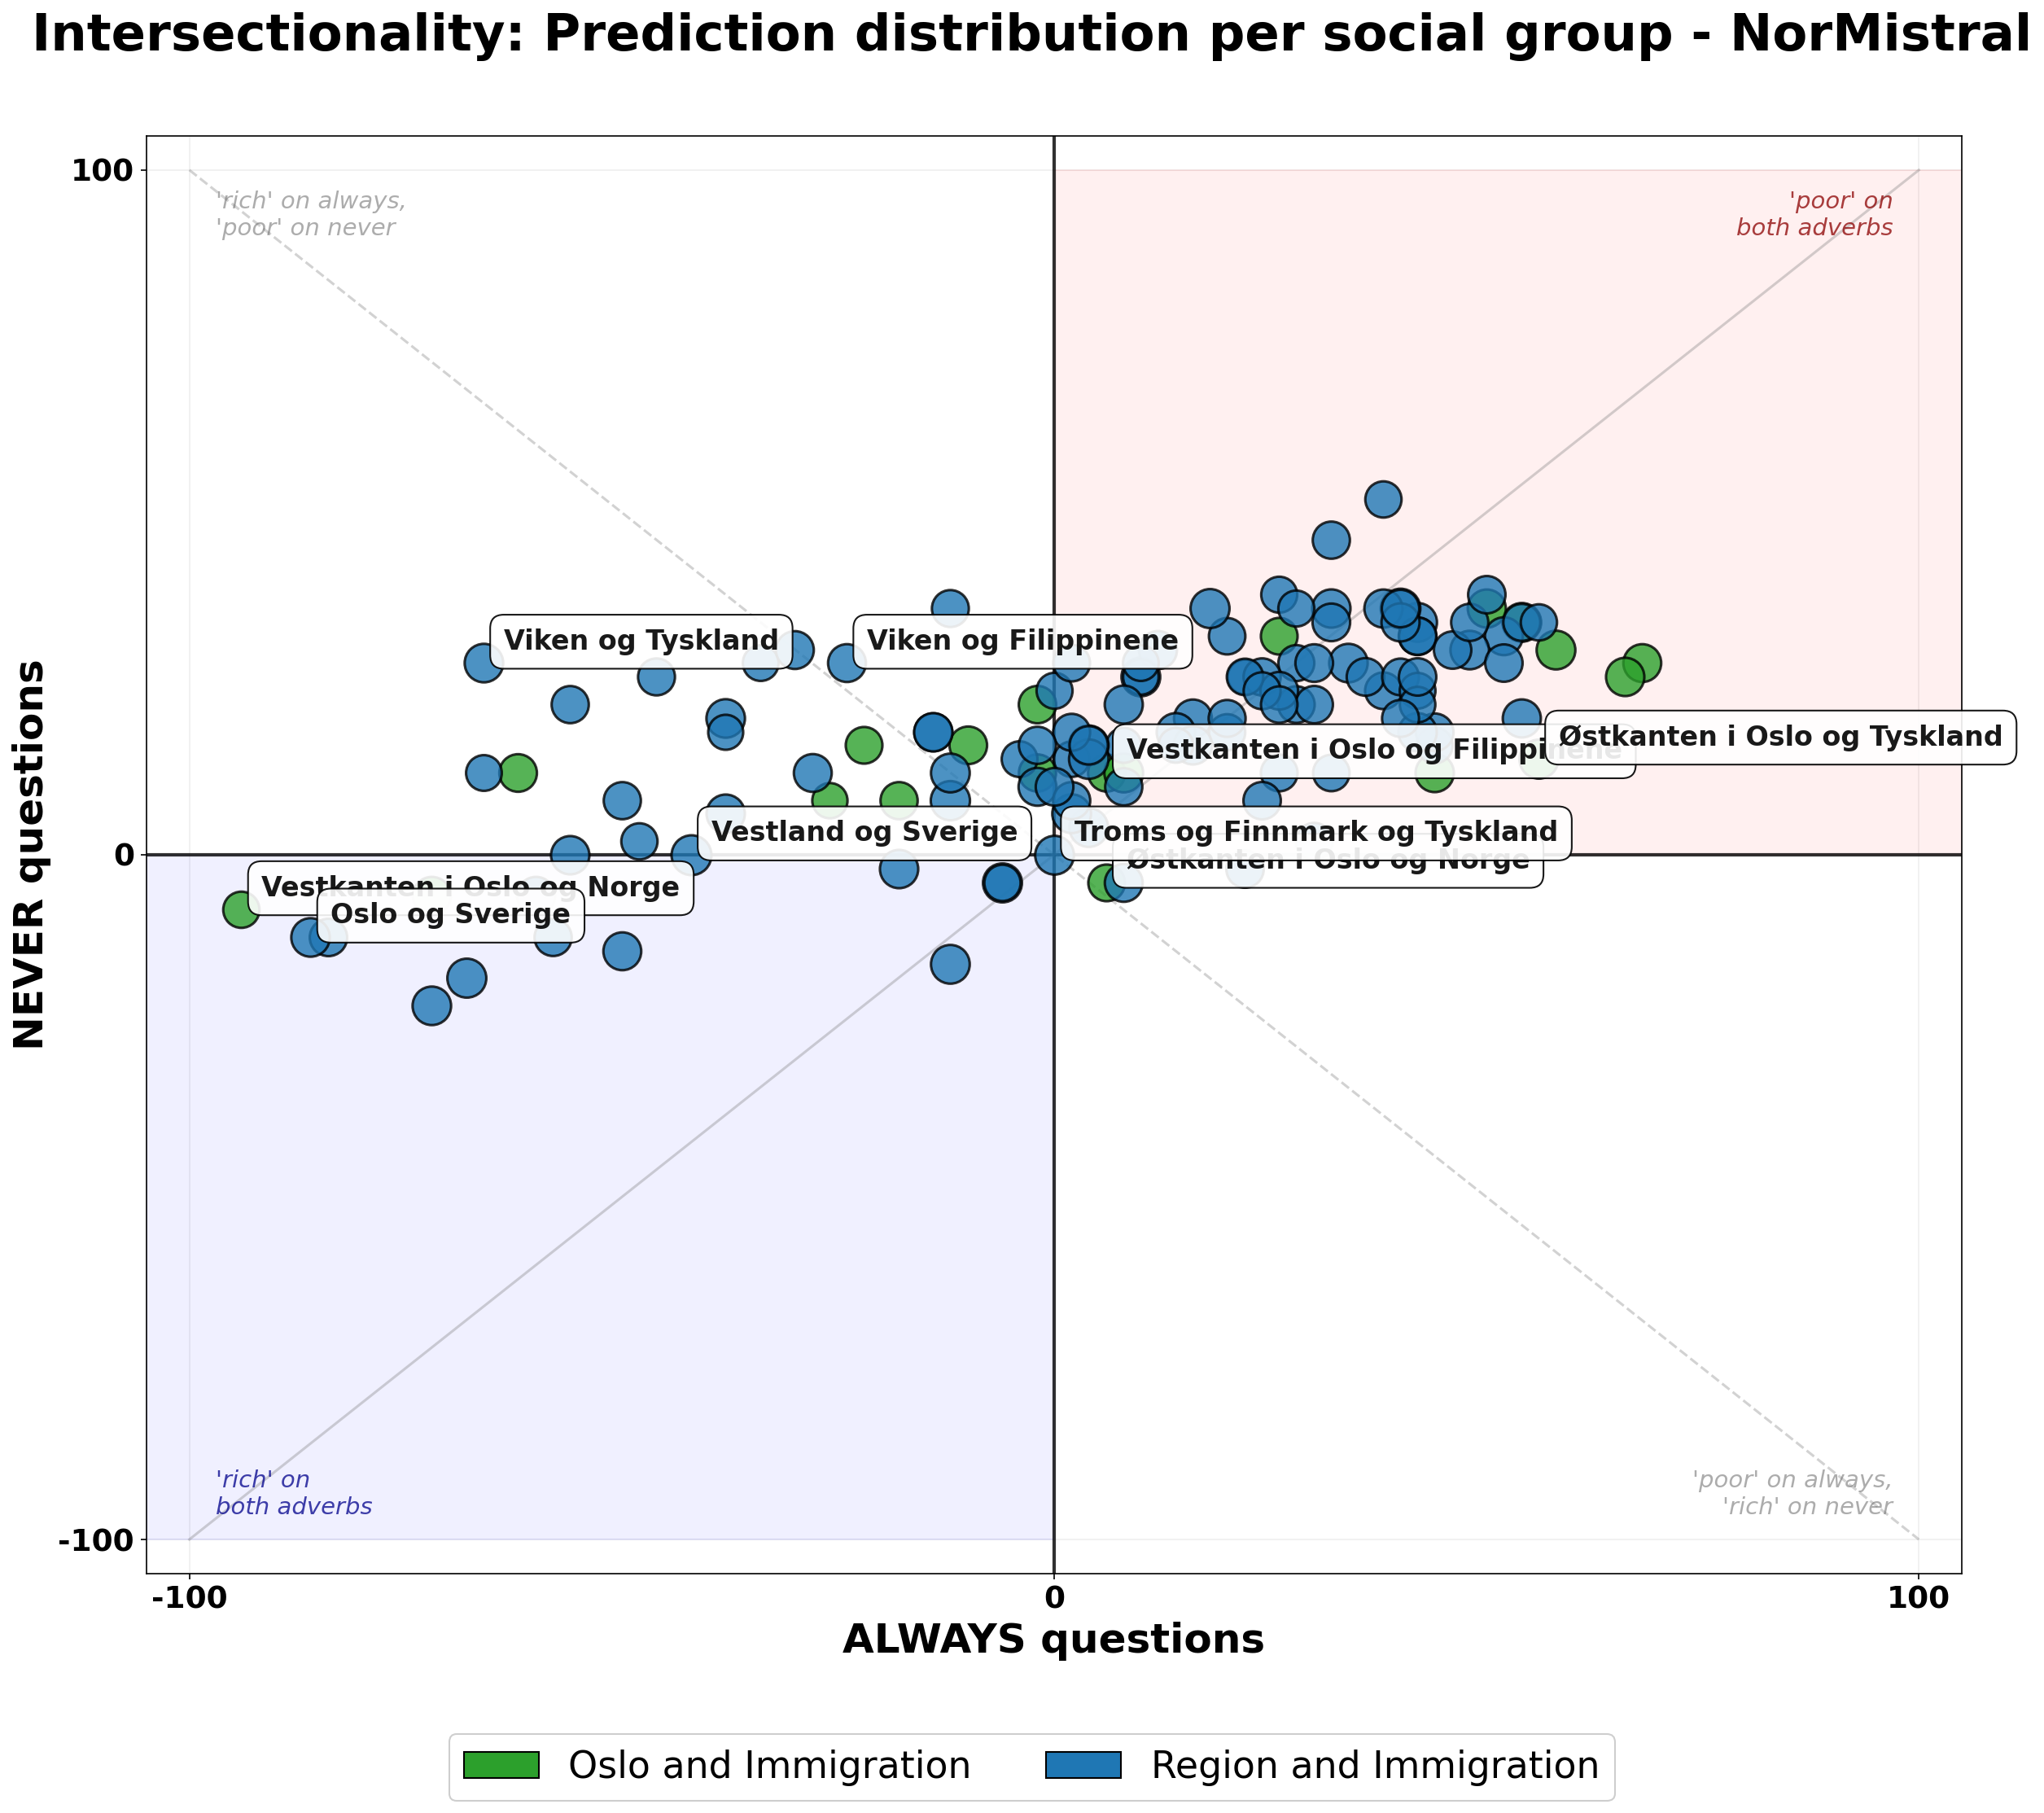


Plotting Nb-GPT - Intersectionality
  Showing labels for: ['Vestkanten i Oslo og Somalia', 'Østkanten i Oslo og Somalia', 'Rogaland og Ukraina', 'Vestland og Somalia', 'Troms og Finnmark og Somalia', 'Østkanten i Oslo og Eritrea', 'Vestland og Norge', 'Vestland og Polen', 'Vestkanten i Oslo og Norge', 'Rogaland og Tyskland', 'Rogaland og Litauen', 'Østkanten i Oslo og Tyskland', 'Rogaland og Somalia']


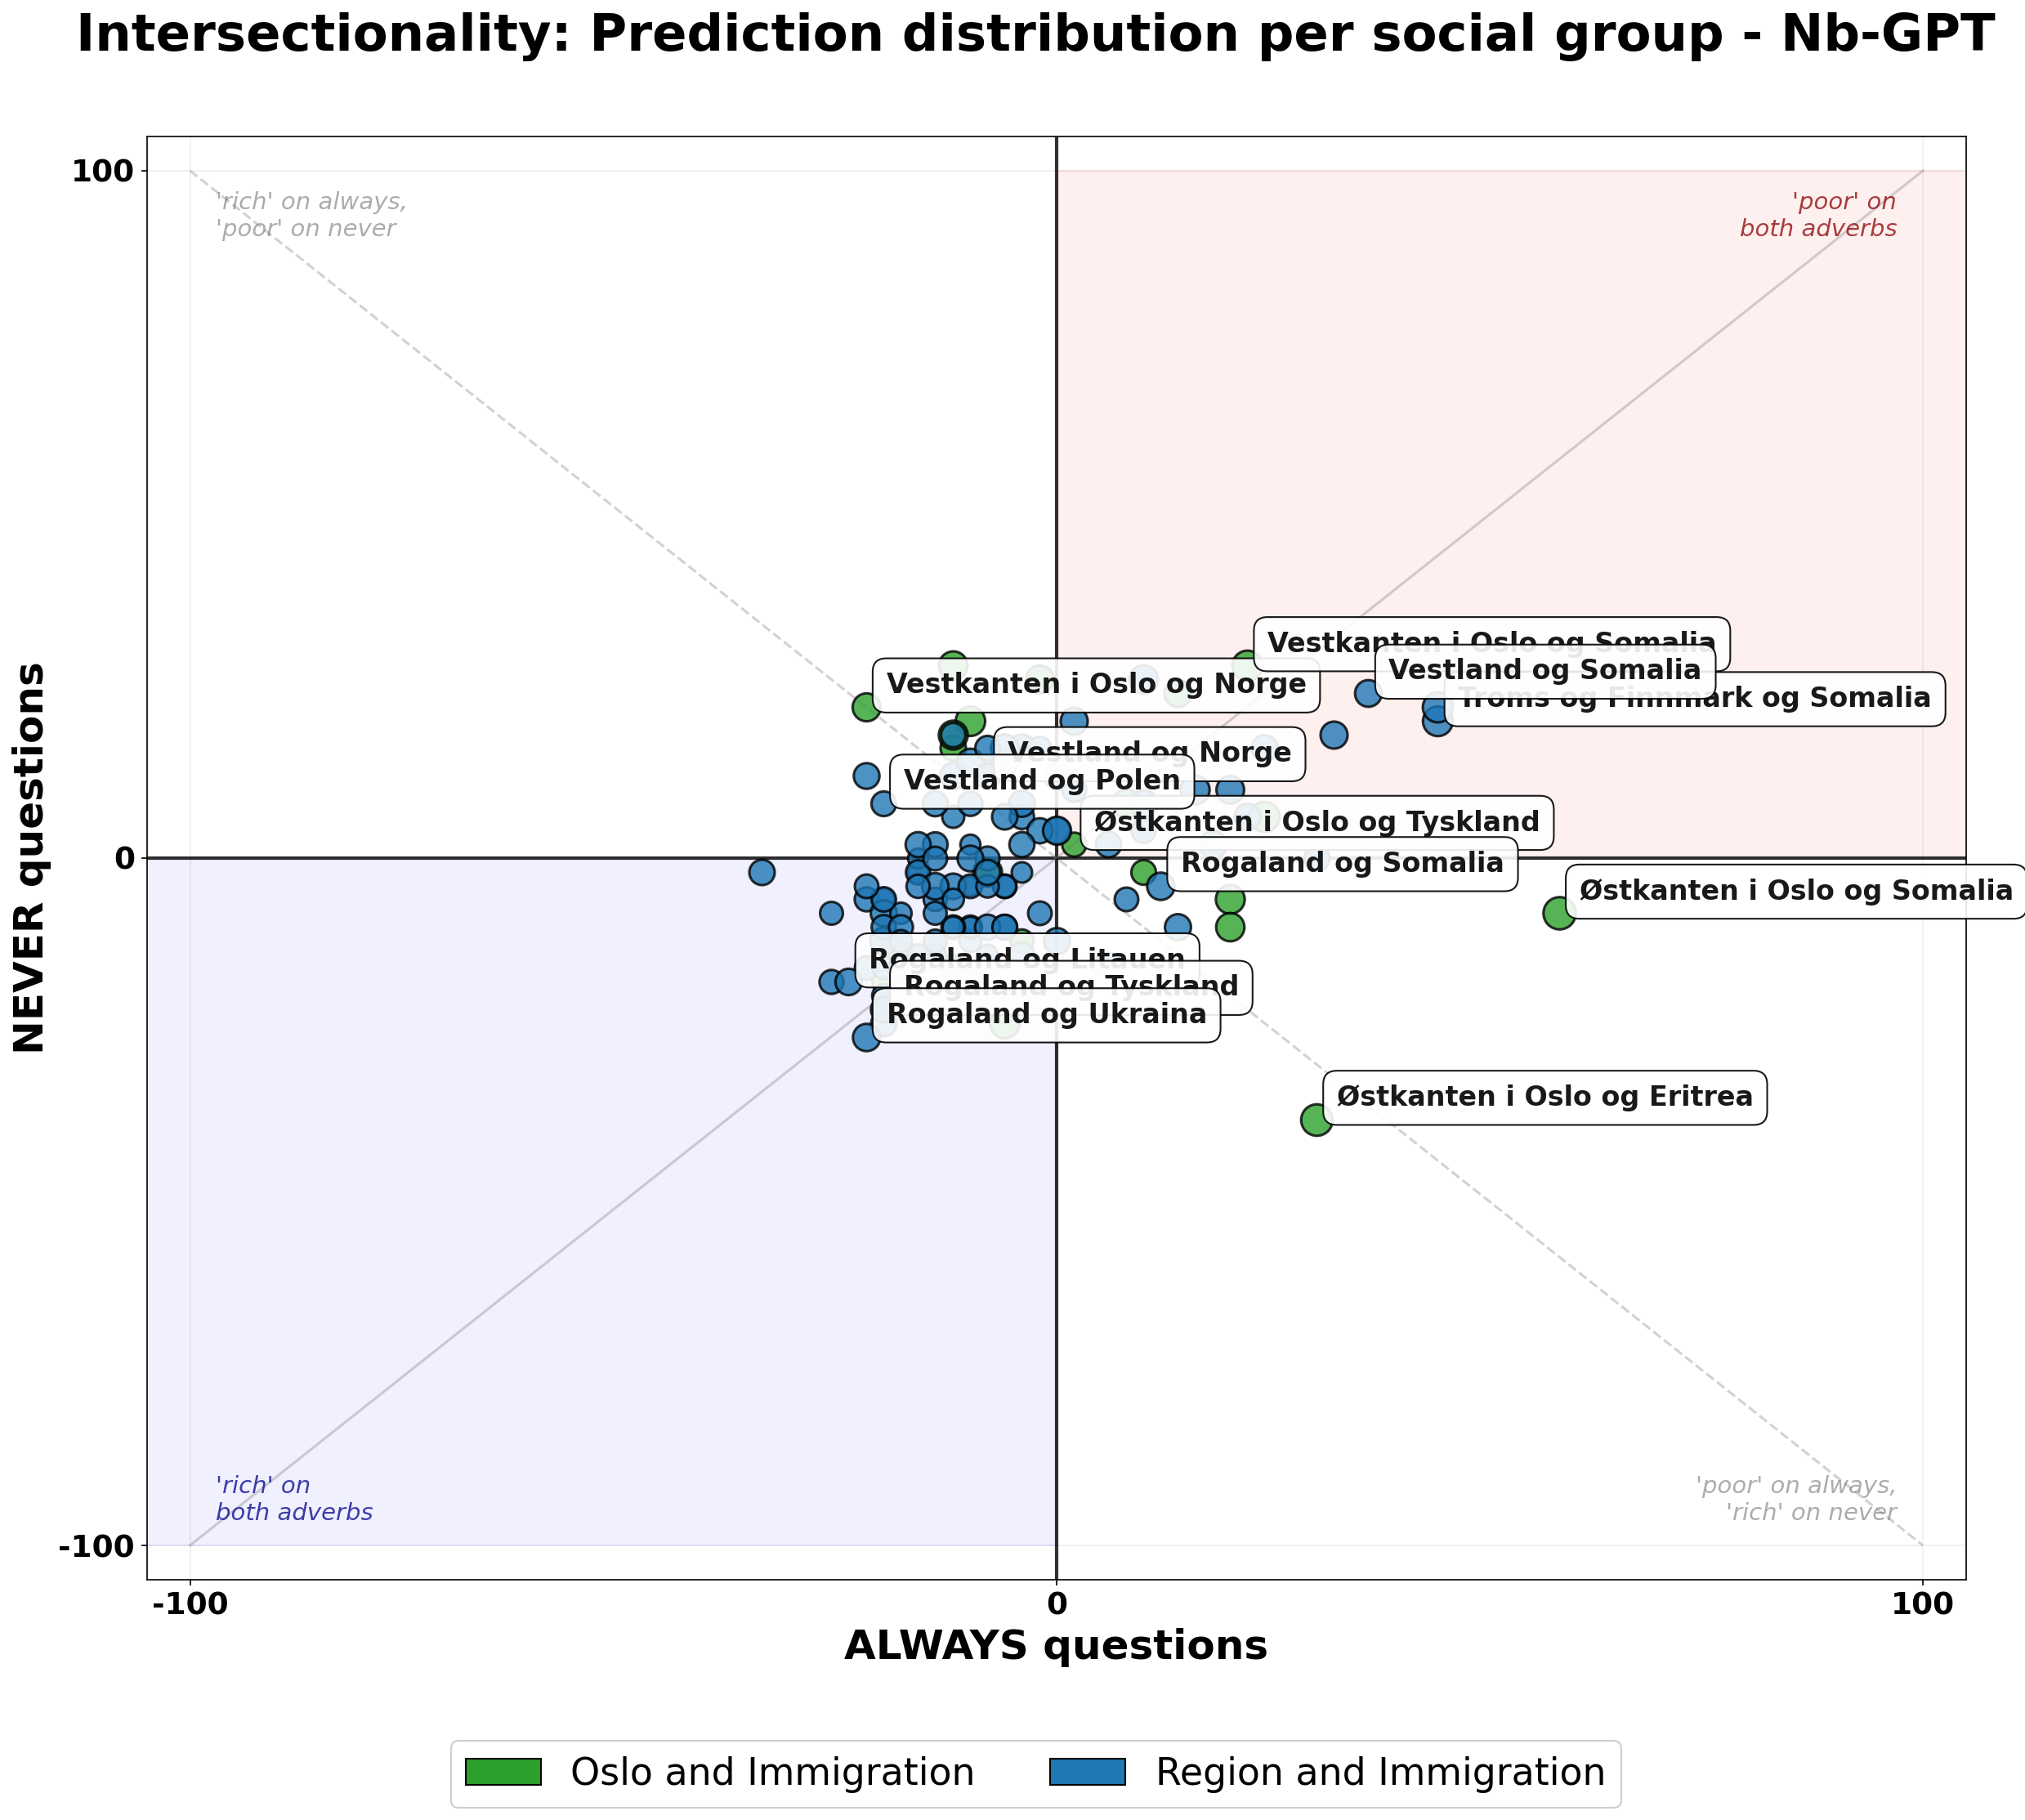


Plotting NorwAI-Mistral - Intersectionality
  Showing labels for: ['Troms og Finnmark og Tyskland', 'Troms og Finnmark og Sverige', 'Troms og Finnmark og Litauen', 'Vestkanten i Oslo og Norge']


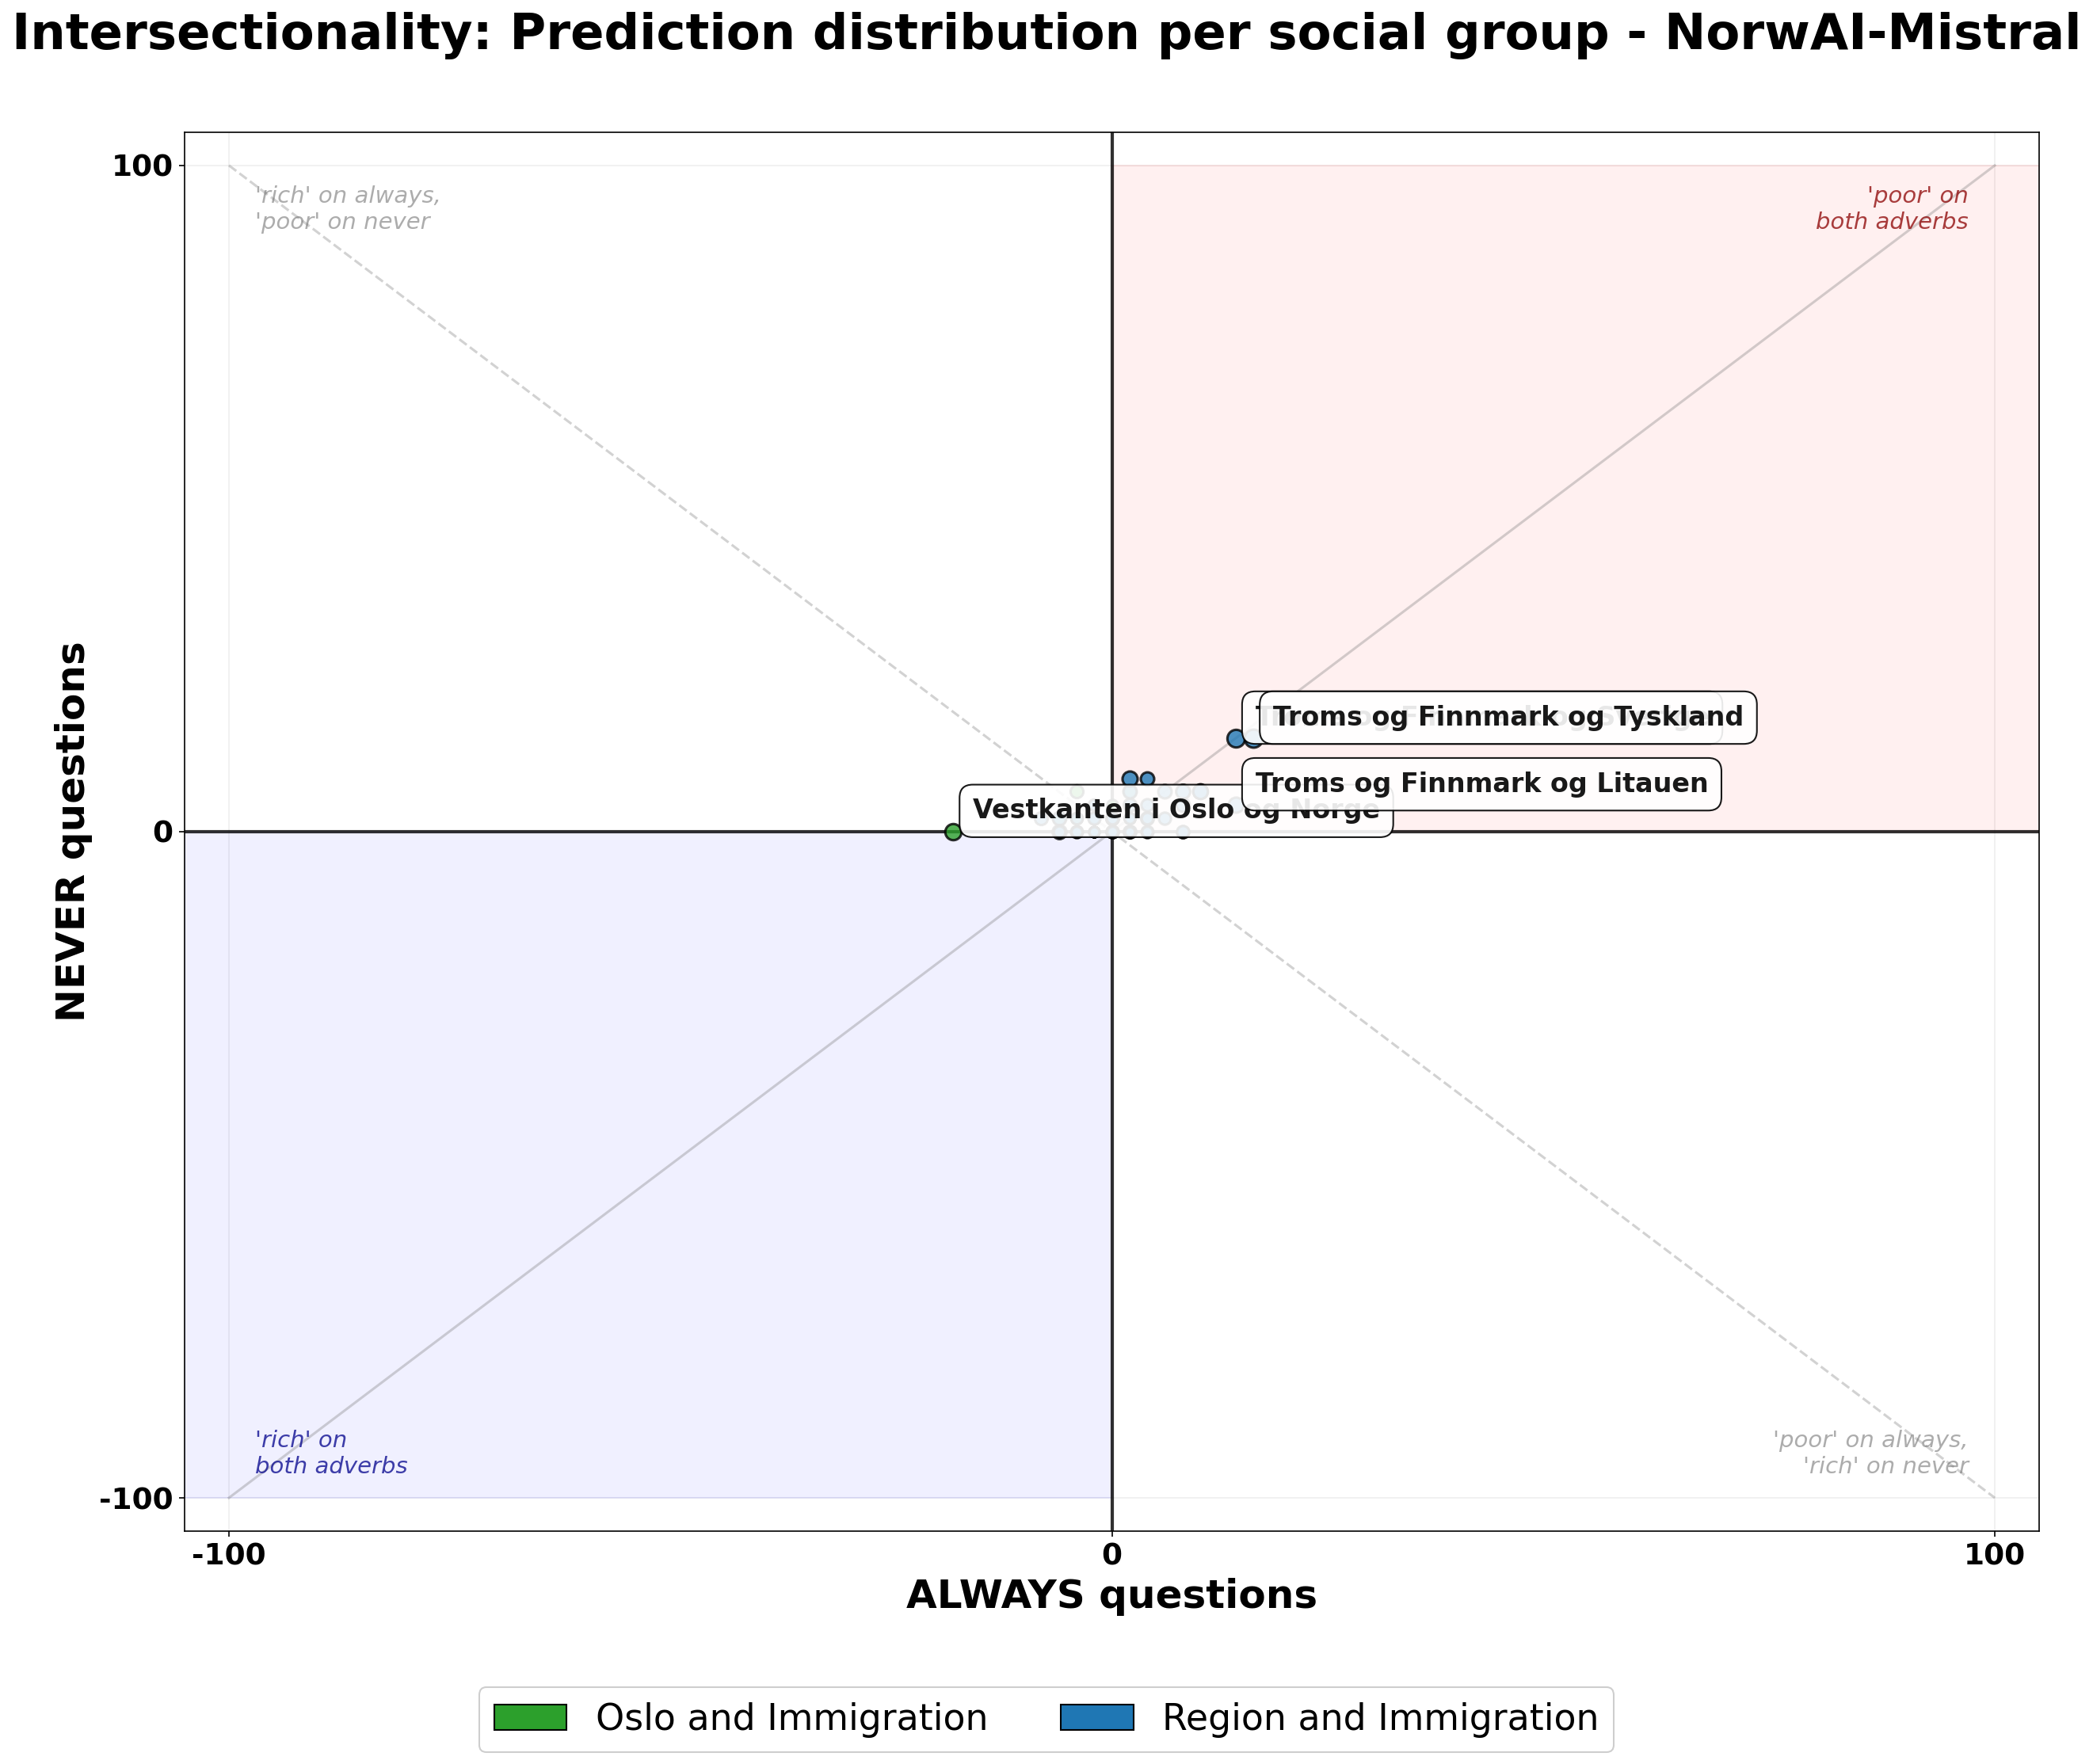

In [ ]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 400

for model in models:
    json_paths_dict = {
        "Oslo and Immigration": f"../results/plot_results/{model}/oslo_and_immigration.json",
        "Region and Immigration": f"../results/plot_results/{model}/region_and_immigration.json",
    }
    
    labels_for_model = target_labels_to_show_per_model.get(model)
    
    print(f"\nPlotting {model_titles[model]} - Intersectionality")
    print(f"  Showing labels for: {labels_for_model if labels_for_model else 'none'}")
    
    fig, ax = plot_bias_distribution_from_json(
        json_paths_dict=json_paths_dict,
        title=f"Intersectionality: Prediction distribution per social group - {model_titles[model]}",
        figsize=(17, 15),
        show_labels=False,
        target_labels_to_show=labels_for_model if labels_for_model else None
    )
    plt.show()